# General versus group-specific Tibia Coin models

## tl;dr

The hierarchical family creates one model per sufficiently populated PvP × BattlEye ×
region group, pooling locations first and BattlEye cohorts second when samples are small.
PvP types are never mixed. On the untouched final holdout, the general model remains the
default because it has lower aggregate RMSE. The specific family is retained as an
interactive diagnostic and alternative score.

## Context & Methods

Both families predict the seven-day change in a world's log-price deviation from the
cross-world mean. The first 70% of dates train estimator selection, the next 15% validate
pooling sensitivity, and the final 15% are opened once for comparison. Seven dates are purged
between estimation and evaluation windows.

### Key assumptions

- BattlEye green means protected since world release; yellow means protection was retrofitted.
- The preferred group minimum is five eligible worlds.
- Pooling order is location, then BattlEye; PvP is always isolated.
- Lower RMSE is better. A positive “specific improvement” means the specific family wins.

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
P = ROOT / "data" / "processed"
registry = pd.read_csv(P / "specific_model_registry.csv")
comparison = pd.read_csv(P / "specific_model_comparison.csv")
sensitivity = pd.read_csv(P / "specific_model_sensitivity.csv")
latest = pd.read_csv(P / "latest_specific_predictions.csv")
results = json.loads((P / "specific_model_results.json").read_text())

## Data

In [2]:
coverage = (
    registry.groupby("group_level", observed=True)
    .agg(worlds=("world", "nunique"), models=("group_id", "nunique"))
    .rename(index={
        "pvp_battleye_region": "Exact PvP × BattlEye × region",
        "pvp_battleye": "Regions pooled",
        "pvp": "Regions + BattlEye pooled",
    })
)
coverage

,worlds,models
group_level,,
Regions + BattlEye pooled,10,2
Regions pooled,17,3
Exact PvP × BattlEye × region,34,6


In [3]:
groups = (
    registry[[
        "group_id", "pvp_type", "group_level", "model_worlds",
        "assigned_worlds", "selected_estimator", "low_sample_warning",
    ]]
    .drop_duplicates("group_id")
    .sort_values(["pvp_type", "group_level", "group_id"])
)
groups

,group_id,pvp_type,group_level,model_worlds,assigned_worlds,selected_estimator,low_sample_warning
0,open-pvp__green__all-regions,Open PvP,pvp_battleye,9,4,random_forest,False
9,open-pvp__yellow__all-regions,Open PvP,pvp_battleye,14,8,ridge,False
4,open-pvp__green__south-america,Open PvP,pvp_battleye_region,5,5,ridge,False
13,open-pvp__yellow__north-america,Open PvP,pvp_battleye_region,6,6,random_forest,False
23,optional-pvp__green__all-regions,Optional PvP,pvp_battleye,10,5,ridge,False
28,optional-pvp__green__south-america,Optional PvP,pvp_battleye_region,5,5,random_forest,False
33,optional-pvp__yellow__europe,Optional PvP,pvp_battleye_region,6,6,random_forest,False
39,optional-pvp__yellow__north-america,Optional PvP,pvp_battleye_region,7,7,ridge,False
46,optional-pvp__yellow__south-america,Optional PvP,pvp_battleye_region,5,5,ridge,False
51,retro-hardcore-pvp__all-battleye__all-regions,Retro Hardcore PvP,pvp,3,3,ridge,True


## Results

In [4]:
headline = comparison.query("scope == 'all'")[[
    "n_worlds", "n_dates", "general_rmse_pct", "specific_rmse_pct",
    "specific_improvement_pct", "dm_p_specific_vs_general", "better_model",
]]
headline

,n_worlds,n_dates,general_rmse_pct,specific_rmse_pct,specific_improvement_pct,dm_p_specific_vs_general,better_model
0,61,121,1.86738,1.885031,-0.945215,0.027081,general


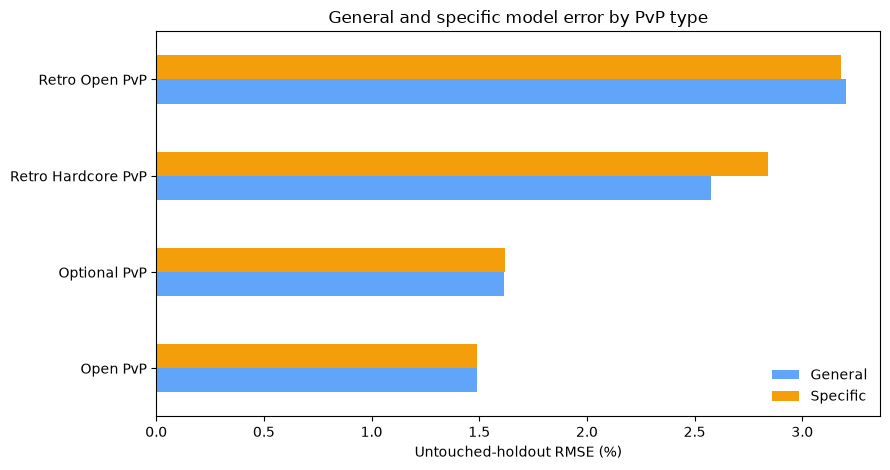

In [5]:
by_pvp = comparison.query("scope == 'pvp_type'").copy()
chart = by_pvp.set_index("scope_value")[["general_rmse_pct", "specific_rmse_pct"]]
ax = chart.plot.barh(figsize=(9, 4.8), color=["#60a5fa", "#f59e0b"])
ax.set_xlabel("Untouched-holdout RMSE (%)")
ax.set_ylabel("")
ax.set_title("General and specific model error by PvP type")
ax.legend(["General", "Specific"], frameon=False)
plt.tight_layout()
plt.show()

In [6]:
sensitivity[[
    "min_group_worlds", "n_models", "n_exact_worlds",
    "n_region_pooled_worlds", "n_pvp_pooled_worlds",
    "general_rmse_pct", "specific_rmse_pct",
]]

,min_group_worlds,n_models,n_exact_worlds,n_region_pooled_worlds,n_pvp_pooled_worlds,general_rmse_pct,specific_rmse_pct
0,4,13,42,13,6,2.054363,2.489171
1,5,11,34,17,10,2.054363,2.331795
2,6,9,19,32,10,2.054363,2.330607


## Takeaways

- The requested hierarchy is fully represented: every eligible world receives exactly one
  model, and no training pool crosses PvP types.
- The five-world threshold is preferable to four in validation, but six is almost identical;
  the conclusion is not driven by one arbitrary cutoff.
- The general model wins the aggregate untouched holdout. The segment-specific scores should
  therefore be treated as exploratory context rather than a replacement production default.
- Retro Hardcore PvP has only three eligible worlds. It remains isolated, uses regularized
  Ridge, and carries a visible low-sample warning.

In [7]:
overall = comparison.query("scope == 'all'").iloc[0]
print(
    f"Verified conclusion: {overall.better_model} wins — "
    f"general RMSE {overall.general_rmse_pct:.3f}% vs "
    f"specific {overall.specific_rmse_pct:.3f}%, "
    f"specific improvement {overall.specific_improvement_pct:+.2f}%."
)

Verified conclusion: general wins — general RMSE 1.867% vs specific 1.885%, specific improvement -0.95%.
